# Imports

In [21]:
import mne
import mne.io
import numpy as np
import pandas as pd

from pathlib import Path
import matplotlib.pyplot as plt

# Data Load

In [13]:
eeg_file_path_format = 'openneuro_data/sub-{number:03}/eeg/sub-{number:03}_task-eyesclosed_eeg.set'

X = pd.DataFrame()

for n in range(1, 66):
    file_path = eeg_file_path_format.format(number=n)
    raw = mne.io.read_raw_eeglab(file_path, preload=True)
    data = raw.to_data_frame()
    data.drop('time', axis=1, inplace=True)
    data = pd.Series(data.to_numpy().flatten()).iloc[:19*500*60] # number of leads * sampling rate * one minute
    data = data.reset_index(drop=True)
    X = pd.concat([X, data.to_frame().T], ignore_index=True)

X.head()

C:\Users\Nathaniel Byrd\AppData\Local\Temp\ipykernel_36216\706222344.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True)
C:\Users\Nathaniel Byrd\AppData\Local\Temp\ipykernel_36216\706222344.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True)
C:\Users\Nathaniel Byrd\AppData\Local\Temp\ipykernel_36216\706222344.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True)
C:\Users\Nathaniel Byrd\AppData\Local\Temp\ipykernel_36216\706222344.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious

,0,1,2,3,4,5,6,7,8,9,...,569990,569991,569992,569993,569994,569995,569996,569997,569998,569999
0,-33.716686,-25.142326,-10.501626,-15.470965,-14.639780,-18.083931,-12.670144,-15.455706,-14.112548,-14.500907,...,4.364652,12.321169,5.190127,9.251271,14.905151,-2.129404,1.619568,16.560631,15.665541,0.182871
1,-13.547649,-12.982911,-12.864223,-15.478166,-14.479111,-13.763200,-12.896243,-12.010491,-10.874237,-16.251282,...,-1.943519,-4.998881,2.232542,-13.200681,6.055850,-9.795838,-4.560695,6.273421,3.562891,-3.349273
2,-1.384971,0.310200,-3.326930,2.742624,0.656810,3.078944,2.110509,8.903687,2.517761,15.549582,...,15.774401,12.967416,28.860413,11.998049,21.113153,16.219852,10.650066,14.144662,15.595396,17.984926
3,4.723902,0.145953,-1.533589,-2.637750,-2.022448,-3.029307,-5.379206,3.803151,1.642603,-4.996177,...,96.571846,76.500435,83.662346,79.810936,89.040573,86.210373,95.136421,91.285057,100.751297,95.969452
4,-19.379652,-20.684259,-38.117813,-33.889000,-24.819490,-22.959326,-23.725227,-22.191916,-16.936806,-26.684614,...,62.167995,70.343597,67.459465,65.295731,62.515858,62.368153,62.502682,59.641628,61.743698,60.794277


In [3]:
X.describe()

,0,1,2,3,4,5,6,7,8,9,...,28490,28491,28492,28493,28494,28495,28496,28497,28498,28499
0,-33.716686,-25.142326,-10.501626,-15.470965,-14.639780,-18.083931,-12.670144,-15.455706,-14.112548,-14.500907,...,84.186966,80.656410,80.066750,75.867516,82.771355,80.002563,84.764076,78.216400,82.228630,80.900940
1,-13.547649,-12.982911,-12.864223,-15.478166,-14.479111,-13.763200,-12.896243,-12.010491,-10.874237,-16.251282,...,7.027158,-1.294021,-3.387452,1.531427,2.273715,5.826613,8.252597,-2.182768,0.874269,-0.911403
2,-1.384971,0.310200,-3.326930,2.742624,0.656810,3.078944,2.110509,8.903687,2.517761,15.549582,...,-33.552906,-42.946068,-40.402092,-30.880066,-41.598820,-27.987234,-48.225449,-37.611465,-25.235281,-24.168118
3,4.723902,0.145953,-1.533589,-2.637750,-2.022448,-3.029307,-5.379206,3.803151,1.642603,-4.996177,...,-4.494199,-10.819843,-1.529887,-13.284366,-3.820531,-12.729028,-3.611506,-15.833203,-15.153379,-9.968896
4,-19.379652,-20.684259,-38.117813,-33.889000,-24.819490,-22.959326,-23.725227,-22.191916,-16.936806,-26.684614,...,-24.003325,-17.608561,-20.980371,-31.881996,-19.497616,-25.899683,-23.272934,-27.048422,-21.935608,-26.034338


In [12]:
labels_file_path = 'openneuro_data/participants.tsv'

Y = pd.read_csv(labels_file_path, sep='\t')
Y = Y['Group'].iloc[:65]
Y.head()

0    A
1    A
2    A
3    A
4    A
Name: Group, dtype: str

In [5]:
Y.describe()

count     65
unique     2
top        A
freq      36
Name: Group, dtype: object

# Plotting

## Get P3 lead

In [27]:
# Choosing sub-001 for AD and sub-065 for HC
# P3 lead : index % 19 == 6
P3_lead_AD = X.iloc[0] # get sub-001
P3_lead_HC = X.iloc[64] # get sub-065

P3_lead_AD = P3_lead_AD[P3_lead_AD.index % 19 == 6] # keep only lead #6 (zero-indexed), which is P3
P3_lead_HC = P3_lead_HC[P3_lead_HC.index % 19 == 6]

P3_lead_AD.reset_index(inplace=True, drop=True)
P3_lead_HC.reset_index(inplace=True, drop=True)

P3_lead_AD

0       -12.670144
1       -11.895370
2       -11.468915
3       -11.322964
4       -11.326547
           ...    
29995    -6.689664
29996    -5.862956
29997    -4.438766
29998    -2.528227
29999    -0.350058
Name: 0, Length: 30000, dtype: float64

## Plot

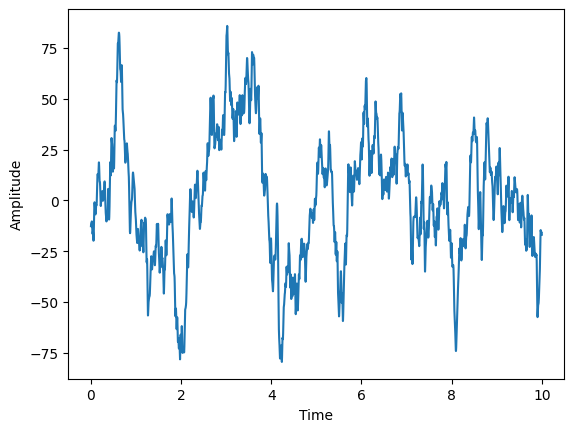

In [28]:
P3_lead_AD.index /= 500 # convert index to time
P3_lead_AD = P3_lead_AD.loc[:10] # take first 10 seconds

P3_lead_AD.plot()
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

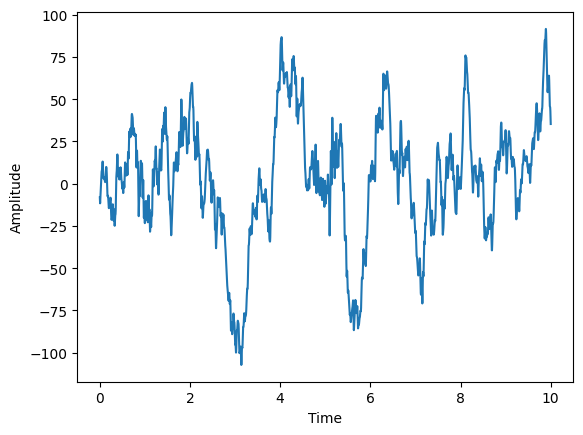

In [29]:
P3_lead_HC.index /= 500 # convert index to time
P3_lead_HC = P3_lead_HC.loc[:10] # take first 10 seconds

P3_lead_HC.plot()
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()